# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up for inline plotting in Jupyter
%matplotlib inline

# Load the Dataset

In [2]:
# Load all CSV files into DataFrames
customers_df = pd.read_csv('files/olist_customers_dataset.csv')
geolocation_df = pd.read_csv('files/olist_geolocation_dataset.csv')
order_items_df = pd.read_csv('files/olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('files/olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv('files/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('files/olist_orders_dataset.csv')
products_df = pd.read_csv('files/olist_products_dataset.csv')
sellers_df = pd.read_csv('files/olist_sellers_dataset.csv')
translation_df = pd.read_csv('files/product_category_name_translation.csv')

# Display the shape of each DataFrame
print("Customers:", customers_df.shape)
print("Geolocation:", geolocation_df.shape)
print("Order Items:", order_items_df.shape)
print("Order Payments:", order_payments_df.shape)
print("Order Reviews:", order_reviews_df.shape)
print("Orders:", orders_df.shape)
print("Products:", products_df.shape)
print("Sellers:", sellers_df.shape)
print("Translation:", translation_df.shape)

Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Translation: (71, 2)


# Inspect Data Structure

In [3]:
# Inspect the structure of key DataFrames
print("Orders DataFrame:")
print(orders_df.head())
print("\nInfo:")
print(orders_df.info())
print("\nDescribe:")
print(orders_df.describe())

print("\n\nCustomers DataFrame:")
print(customers_df.head())
print("\nInfo:")
print(customers_df.info())
print("\nDescribe:")
print(customers_df.describe())

Orders DataFrame:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00

# Handle Missing Values

In [4]:
# Check for missing values in each DataFrame
print("Missing values in Orders:")
print(orders_df.isnull().sum())

print("\nMissing values in Customers:")
print(customers_df.isnull().sum())

print("\nMissing values in Order Items:")
print(order_items_df.isnull().sum())

print("\nMissing values in Products:")
print(products_df.isnull().sum())

# For demonstration, fill missing values in orders_df (if any)
# orders_df.fillna(method='ffill', inplace=True)  # Example: forward fill
# But since it's basic, we'll just note them

Missing values in Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in Customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values in Order Items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in Products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_len

# Basic Descriptive Statistics

In [5]:
# Basic descriptive statistics
print("Order Status Counts:")
print(orders_df['order_status'].value_counts())

print("\nPayment Type Counts:")
print(order_payments_df['payment_type'].value_counts())

print("\nProduct Category Counts:")
print(products_df['product_category_name'].value_counts().head(10))  # Top 10

print("\nNumerical summaries for Order Items:")
print(order_items_df[['price', 'freight_value']].describe())

Order Status Counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Payment Type Counts:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Product Category Counts:
product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

Numerical summaries for Order Items:
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25% 

# Explore Categorical Variables

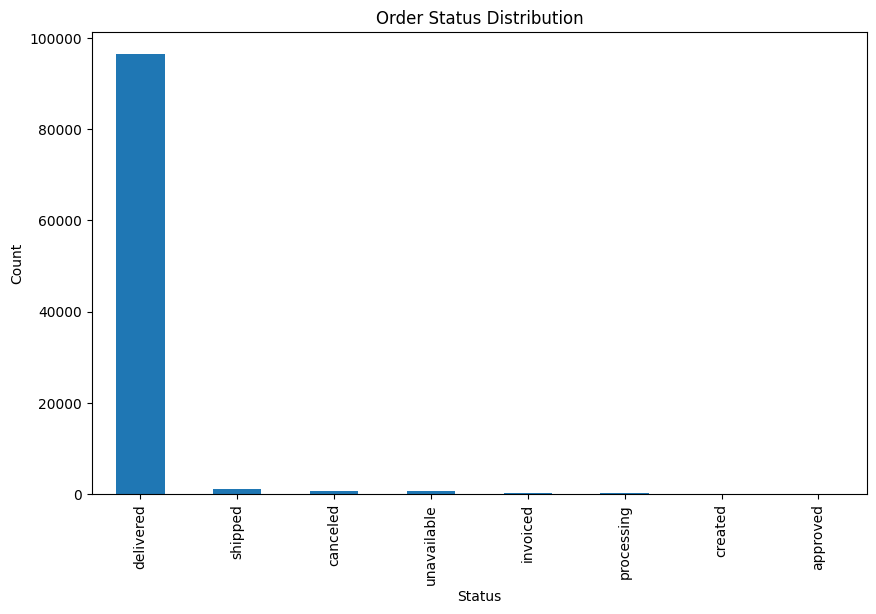

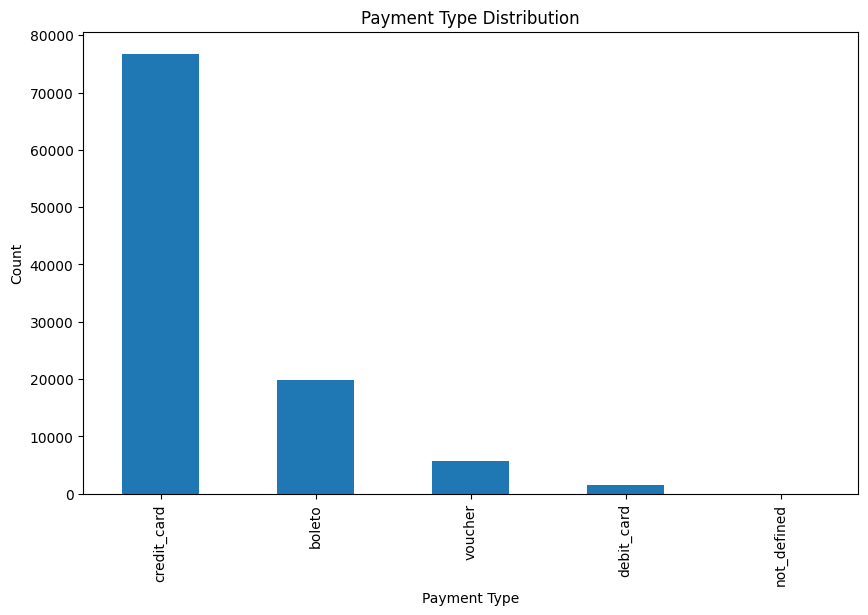

In [6]:
# Visualize categorical variables
plt.figure(figsize=(10, 6))
orders_df['order_status'].value_counts().plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
order_payments_df['payment_type'].value_counts().plot(kind='bar')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.show()

# Visualize Numerical Distributions

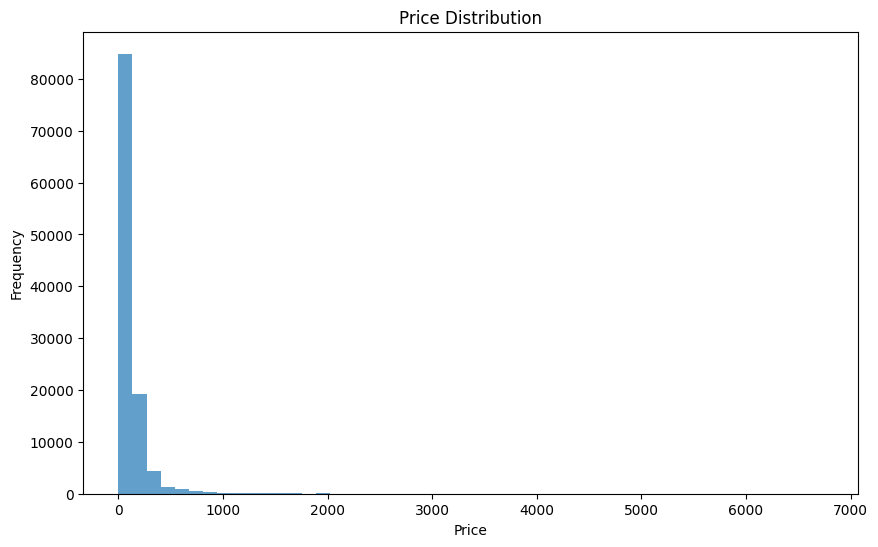

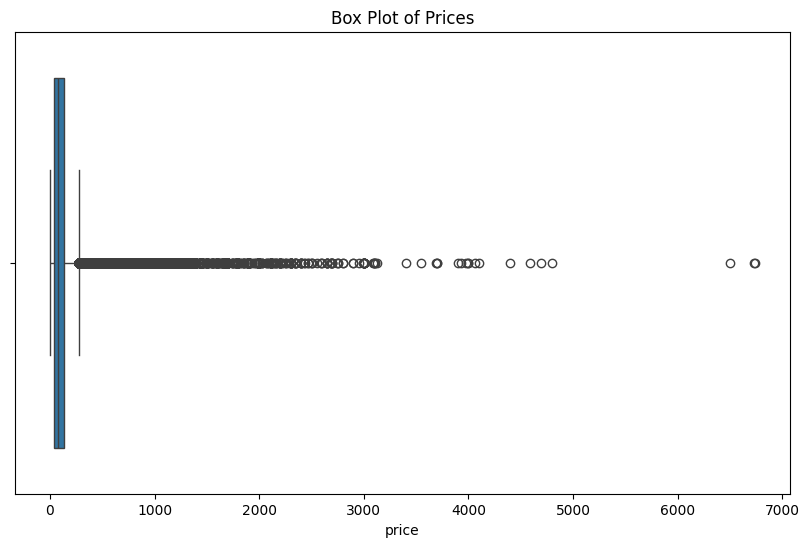

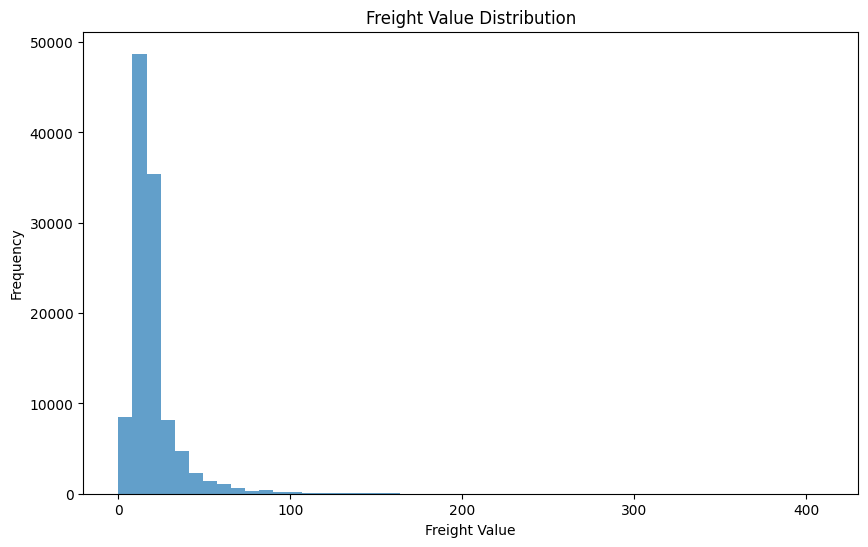

In [7]:
# Visualize numerical distributions
plt.figure(figsize=(10, 6))
plt.hist(order_items_df['price'], bins=50, alpha=0.7)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=order_items_df['price'])
plt.title('Box Plot of Prices')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(order_items_df['freight_value'], bins=50, alpha=0.7)
plt.title('Freight Value Distribution')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')
plt.show()